# Hybrid Airbnb Demand Network

This notebook combines the three standalone model structures into one PyTorch-based hybrid pipeline for predicting high-demand Airbnb listings in New York City.

The pipeline uses:

1. The standalone sentiment model structure: an embedding + LSTM text model trained from VADER sentiment labels.
2. The standalone CNN structure: a map-patch convolutional model trained from latitude/longitude patches.
3. The standalone tabular neural network structure: dense 64 -> dropout -> dense 32 -> dropout -> output.

The final tabular model receives the original structured inputs plus the two auxiliary outputs:

- `sentiment_prob`
- `cnn_demand_prob`

The final target is `high_demand`: listings in the top 25% of `reviews_per_month`.

The auxiliary feature generators are trained on `aux_train_df`, while the final hybrid model is trained on `hybrid_train_df`. This avoids training the final model on auxiliary predictions from models that already saw those exact rows.


## 1. Setup and configuration

In [2]:
# Install the project dependencies first if needed:
# !pip install -r requirements.txt

import re
import random
import warnings
from collections import Counter
from io import BytesIO
from urllib.request import urlopen

import nltk
import numpy as np
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
from PIL import Image

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


CONFIG = {
    "batch_size": 32,
    "sentiment_epochs": 5,
    "cnn_epochs": 30,
    "tabular_epochs": 20,
    "sentiment_embed_dim": 100,
    "sentiment_hidden_dim": 128,
    "patch_size": 32,
    "sentiment_learning_rate": 1e-3,
    "cnn_learning_rate": 5e-4,
    "tabular_learning_rate": 1e-3,
}

def fetch_url_bytes(url, timeout=20):
    with urlopen(url, timeout=timeout) as response:
        return response.read()

class ArrayDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(np.asarray(X, dtype=np.float32), dtype=torch.float32)
        self.y = None if y is None else torch.tensor(np.asarray(y, dtype=np.float32), dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is None:
            return self.X[idx]
        return self.X[idx], self.y[idx]

class TabularNN(nn.Module):
    """PyTorch equivalent of the standalone Keras tabular network."""
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

def train_tabular_nn(model, X_train, y_train, X_val, y_val, *, epochs, model_name):
    train_loader = DataLoader(ArrayDataset(X_train, y_train), batch_size=CONFIG["batch_size"], shuffle=True)
    model = model.to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["tabular_learning_rate"])

    for epoch in range(epochs):
        model.train()
        losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = criterion(model(xb), yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        val_prob = predict_binary_prob(model, X_val)
        val_pred = (val_prob >= 0.5).astype(int)
        val_auc = roc_auc_score(y_val, val_prob) if len(np.unique(y_val)) > 1 else np.nan
        val_acc = accuracy_score(y_val, val_pred)
        print(f"{model_name} epoch {epoch + 1}/{epochs} - loss={np.mean(losses):.4f}, val_acc={val_acc:.4f}, val_auc={val_auc:.4f}")

    return model

def predict_binary_prob(model, X):
    loader = DataLoader(ArrayDataset(X), batch_size=CONFIG["batch_size"], shuffle=False)
    model.eval()
    probs = []
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(DEVICE)
            probs.extend(torch.sigmoid(model(xb)).cpu().numpy())
    return np.asarray(probs, dtype=np.float32)

CONFIG


Using device: cpu


{'batch_size': 32,
 'sentiment_epochs': 5,
 'cnn_epochs': 30,
 'tabular_epochs': 20,
 'sentiment_embed_dim': 100,
 'sentiment_hidden_dim': 128,
 'patch_size': 32,
 'sentiment_learning_rate': 0.001,
 'cnn_learning_rate': 0.0005,
 'tabular_learning_rate': 0.001}

## 2. Load Data

The notebook uses the public AB_NYC_2019 dataset directly from one source.


In [3]:
DATA_URL = "https://rossbulat.com/data/ab_nyc_2019.csv"

def load_airbnb_data(url=DATA_URL):
    print(f"Loading dataset: {url}")
    return pd.read_csv(BytesIO(fetch_url_bytes(url))), url

raw_df, data_source = load_airbnb_data()

print("Loaded source:", data_source)
print("Shape:", raw_df.shape)
raw_df.head()


Loading dataset: https://rossbulat.com/data/ab_nyc_2019.csv
Loaded source: https://rossbulat.com/data/ab_nyc_2019.csv
Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## 3. Preprocessing and Target Creation

This keeps only the columns needed by the model, fills missing review rates, removes invalid prices, and creates the high-demand target.


In [4]:
TEXT_COLS = ["name", "host_name", "neighbourhood", "neighbourhood_group"]
NUMERIC_INPUTS = [
    "latitude",
    "longitude",
    "price",
    "minimum_nights",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
]
CATEGORICAL_INPUTS = ["room_type"]
OPTIONAL_OUTPUT_COLS = ["id"]

REQUIRED_COLUMNS = TEXT_COLS + NUMERIC_INPUTS + CATEGORICAL_INPUTS
missing_cols = [c for c in REQUIRED_COLUMNS if c not in raw_df.columns]
if missing_cols:
    raise ValueError(f"Dataset is missing required columns: {missing_cols}")

keep_cols = [c for c in OPTIONAL_OUTPUT_COLS + REQUIRED_COLUMNS if c in raw_df.columns]
df = raw_df[keep_cols].copy()

for col in NUMERIC_INPUTS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[TEXT_COLS + CATEGORICAL_INPUTS] = df[TEXT_COLS + CATEGORICAL_INPUTS].fillna("").astype(str)
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
df = df.dropna(subset=[c for c in NUMERIC_INPUTS if c != "reviews_per_month"])
df = df[df["price"] > 0].copy()

df["price_log"] = np.log1p(df["price"])
df["host_listings_log"] = np.log1p(df["calculated_host_listings_count"])
df["combined_text"] = df[TEXT_COLS].agg(" ".join, axis=1)

# Match the standalone tabular notebook: cap minimum_nights at the full-data 99th percentile.
minimum_nights_cap = df["minimum_nights"].quantile(0.99)
df["minimum_nights"] = df["minimum_nights"].clip(upper=minimum_nights_cap)

demand_threshold = df["reviews_per_month"].quantile(0.75)
df["high_demand"] = (df["reviews_per_month"] >= demand_threshold).astype(int)

print("Demand threshold:", demand_threshold)
print("Minimum nights 99th percentile cap:", minimum_nights_cap)
print("Final dataframe shape:", df.shape)
print(df["high_demand"].value_counts(normalize=True).rename("proportion"))


Demand threshold: 1.58
Minimum nights 99th percentile cap: 45.0
Final dataframe shape: (48884, 17)
high_demand
0    0.748732
1    0.251268
Name: proportion, dtype: float64


## 4. Train/test split and anti-leakage split

The final hybrid model is evaluated only on `test_df`.

The training data is split again into:

- `aux_train_df`: trains the sentiment and CNN feature generators.
- `hybrid_train_df`: trains the final tabular NN using the generated auxiliary features.

This is simpler than full out-of-fold stacking and avoids training the final NN on auxiliary predictions from models trained on the same rows.

In [5]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["high_demand"],
    random_state=SEED,
)

aux_train_df, hybrid_train_df = train_test_split(
    train_df,
    test_size=0.5,
    stratify=train_df["high_demand"],
    random_state=SEED,
)

for name, frame in [("aux_train_df", aux_train_df), ("hybrid_train_df", hybrid_train_df), ("test_df", test_df)]:
    print(name, frame.shape, frame["high_demand"].mean())


aux_train_df (19553, 17) 0.251265790415793
hybrid_train_df (19554, 17) 0.25125294057481845
test_df (9777, 17) 0.2513040810064437


## 5. Sentiment LSTM Feature Generator

This section keeps the standalone sentiment model structure: VADER labels, token ids, padded batches, an embedding layer, one LSTM, and a final linear output layer. The trained model's probability output becomes `sentiment_prob`.


In [6]:
def basic_tokenizer(text):
    return re.findall(r"\b\w+\b", str(text).lower())

try:
    nltk.data.find("sentiment/vader_lexicon.zip")
except LookupError:
    nltk.download("vader_lexicon", quiet=True)

sentiment_analyzer = SentimentIntensityAnalyzer()

def sentiment_label_from_text(text):
    return int(sentiment_analyzer.polarity_scores(str(text))["compound"] > 0)

aux_sentiment_labels = aux_train_df["combined_text"].apply(sentiment_label_from_text).astype(int).values
print("Sentiment label distribution on aux_train_df:", pd.Series(aux_sentiment_labels).value_counts(normalize=True).to_dict())


Sentiment label distribution on aux_train_df: {0: 0.5700404030072111, 1: 0.42995959699278885}


In [7]:
all_tokens = []
for text in aux_train_df["combined_text"]:
    all_tokens.extend(basic_tokenizer(text))

vocab = {tok: idx + 1 for idx, tok in enumerate(set(all_tokens))}
unk_index = 0
vocab_size = len(vocab) + 1

class TextDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.texts = list(texts)
        self.labels = None if labels is None else np.asarray(labels, dtype=np.float32)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = basic_tokenizer(self.texts[idx])
        ids = torch.tensor([vocab.get(tok, unk_index) for tok in tokens], dtype=torch.long)
        if len(ids) == 0:
            ids = torch.tensor([unk_index], dtype=torch.long)
        if self.labels is None:
            return ids
        return ids, torch.tensor(self.labels[idx], dtype=torch.float32)

def collate_text_batch(batch):
    if isinstance(batch[0], tuple):
        texts, labels = zip(*batch)
        texts = nn.utils.rnn.pad_sequence(texts, batch_first=True, padding_value=unk_index)
        labels = torch.stack(labels)
        return texts, labels
    return nn.utils.rnn.pad_sequence(batch, batch_first=True, padding_value=unk_index)

class SentimentModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=unk_index)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        return self.fc(hidden[-1]).squeeze(1)

sentiment_model = SentimentModel(
    vocab_size,
    embed_dim=CONFIG["sentiment_embed_dim"],
    hidden_dim=CONFIG["sentiment_hidden_dim"],
).to(DEVICE)

print("Vocabulary size:", vocab_size)
sentiment_model


Vocabulary size: 10397


SentimentModel(
  (embedding): Embedding(10397, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

In [8]:
sent_train_text, sent_val_text, sent_train_y, sent_val_y = train_test_split(
    aux_train_df["combined_text"].tolist(),
    aux_sentiment_labels.tolist(),
    test_size=0.2,
    stratify=aux_sentiment_labels if len(np.unique(aux_sentiment_labels)) > 1 else None,
    random_state=SEED,
)

sent_train_loader = DataLoader(
    TextDataset(sent_train_text, sent_train_y),
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    collate_fn=collate_text_batch,
)
sent_val_loader = DataLoader(
    TextDataset(sent_val_text, sent_val_y),
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    collate_fn=collate_text_batch,
)

criterion_sent = nn.BCEWithLogitsLoss()
optimizer_sent = torch.optim.Adam(sentiment_model.parameters(), lr=CONFIG["sentiment_learning_rate"])

for epoch in range(CONFIG["sentiment_epochs"]):
    sentiment_model.train()
    losses = []
    for texts, labels in sent_train_loader:
        texts, labels = texts.to(DEVICE), labels.to(DEVICE)
        loss = criterion_sent(sentiment_model(texts), labels)
        optimizer_sent.zero_grad()
        loss.backward()
        optimizer_sent.step()
        losses.append(loss.item())

    sentiment_model.eval()
    val_true, val_pred = [], []
    with torch.no_grad():
        for texts, labels in sent_val_loader:
            texts = texts.to(DEVICE)
            preds = (torch.sigmoid(sentiment_model(texts)).cpu() >= 0.5).float()
            val_true.extend(labels.tolist())
            val_pred.extend(preds.tolist())
    val_acc = accuracy_score(val_true, val_pred)
    print(f"Sentiment epoch {epoch + 1}/{CONFIG['sentiment_epochs']} - loss={np.mean(losses):.4f}, val_acc={val_acc:.4f}")


Sentiment epoch 1/5 - loss=0.4720, val_acc=0.8982
Sentiment epoch 2/5 - loss=0.2309, val_acc=0.9420
Sentiment epoch 3/5 - loss=0.1488, val_acc=0.9517
Sentiment epoch 4/5 - loss=0.1063, val_acc=0.9573
Sentiment epoch 5/5 - loss=0.0821, val_acc=0.9565


In [9]:
def predict_sentiment_prob(texts):
    loader = DataLoader(
        TextDataset(texts, labels=None),
        batch_size=CONFIG["batch_size"],
        shuffle=False,
        collate_fn=collate_text_batch,
    )
    sentiment_model.eval()
    probs = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            probs.extend(torch.sigmoid(sentiment_model(batch)).cpu().numpy())
    return np.asarray(probs, dtype=np.float32)

hybrid_train_df = hybrid_train_df.copy()
test_df = test_df.copy()

hybrid_train_df["sentiment_prob"] = predict_sentiment_prob(hybrid_train_df["combined_text"])
test_df["sentiment_prob"] = predict_sentiment_prob(test_df["combined_text"])

print(hybrid_train_df[["combined_text", "sentiment_prob"]].head())


                                           combined_text  sentiment_prob
43514  Cozy apartment by Central Park Erik Hell's Kit...        0.004633
37613  Private Room 1 - Central Park / CU mins away A...        0.004848
30040  Bright Soho 2 Bedroom Apartment Nima + Kat SoH...        0.986695
22924  Private room in beautiful home in Crown Height...        0.995762
19981  Cozy room in Roosevelt Island. Juan Roosevelt ...        0.004708


## 6. CNN Map-Patch Feature Generator

This section keeps the standalone CNN structure, converted from Keras to PyTorch: two Conv2D + ReLU + MaxPool blocks, global average pooling, a dense 32-unit classifier layer, dropout 0.3, and one binary output. The trained model's probability output becomes `cnn_demand_prob`.


In [10]:
MAP_URL = "https://raw.githubusercontent.com/luitoz/machile-learning-team-project/refs/heads/main/New_York_City_.jpg"

IMG = Image.open(BytesIO(fetch_url_bytes(MAP_URL))).convert("L")
IMG_ARR = np.array(IMG)
H, W = IMG_ARR.shape

lat_min, lat_max = 40.5, 40.92
lon_min, lon_max = -74.25, -73.7
PATCH_SIZE = CONFIG["patch_size"]

def latlon_to_pixel(lat, lon):
    x = (lon - lon_min) / (lon_max - lon_min)
    y = (lat_max - lat) / (lat_max - lat_min)
    px = int(x * (W - 1))
    py = int(y * (H - 1))
    return px, py

def extract_patch(px, py):
    half = PATCH_SIZE // 2
    x1 = max(px - half, 0)
    x2 = min(px + half, W)
    y1 = max(py - half, 0)
    y2 = min(py + half, H)
    patch = IMG_ARR[y1:y2, x1:x2]
    patch = Image.fromarray(patch).resize((PATCH_SIZE, PATCH_SIZE))
    return np.array(patch)

def make_patches(frame):
    patches = []
    for _, row in frame.iterrows():
        px, py = latlon_to_pixel(row["latitude"], row["longitude"])
        patches.append(extract_patch(px, py))
    arr = np.array(patches).astype("float32") / 255.0
    return arr[:, None, :, :]

print("Map image shape:", IMG_ARR.shape)
print("Patch size:", PATCH_SIZE)


Map image shape: (1291, 1326)
Patch size: 32


In [11]:
class PatchDataset(Dataset):
    def __init__(self, patches, labels=None):
        self.patches = torch.tensor(patches, dtype=torch.float32)
        self.labels = None if labels is None else torch.tensor(np.asarray(labels, dtype=np.float32), dtype=torch.float32)

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        if self.labels is None:
            return self.patches[idx]
        return self.patches[idx], self.labels[idx]

class MapPatchCNN(nn.Module):
    """PyTorch equivalent of the standalone Keras map-patch CNN."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

cnn_model = MapPatchCNN().to(DEVICE)
cnn_model


MapPatchCNN(
  (net): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): AdaptiveAvgPool2d(output_size=(1, 1))
    (7): Flatten(start_dim=1, end_dim=-1)
    (8): Linear(in_features=32, out_features=32, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.3, inplace=False)
    (11): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [12]:
cnn_train_df, cnn_val_df = train_test_split(
    aux_train_df,
    test_size=0.2,
    stratify=aux_train_df["high_demand"],
    random_state=SEED,
)

X_cnn_train = make_patches(cnn_train_df)
y_cnn_train = cnn_train_df["high_demand"].values.astype(np.float32)
X_cnn_val = make_patches(cnn_val_df)
y_cnn_val = cnn_val_df["high_demand"].values.astype(np.float32)

cnn_train_loader = DataLoader(
    PatchDataset(X_cnn_train, y_cnn_train),
    batch_size=CONFIG["batch_size"],
    shuffle=True,
)
cnn_val_loader = DataLoader(
    PatchDataset(X_cnn_val, y_cnn_val),
    batch_size=CONFIG["batch_size"],
    shuffle=False,
)

pos = y_cnn_train.sum()
neg = len(y_cnn_train) - pos
pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32, device=DEVICE)
criterion_cnn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_cnn = torch.optim.Adam(cnn_model.parameters(), lr=CONFIG["cnn_learning_rate"])

best_state = None
best_val_loss = np.inf
patience = 2
patience_used = 0

for epoch in range(CONFIG["cnn_epochs"]):
    cnn_model.train()
    losses = []
    for patches, labels in cnn_train_loader:
        patches, labels = patches.to(DEVICE), labels.to(DEVICE)
        loss = criterion_cnn(cnn_model(patches), labels)
        optimizer_cnn.zero_grad()
        loss.backward()
        optimizer_cnn.step()
        losses.append(loss.item())

    cnn_model.eval()
    val_losses, val_true, val_prob = [], [], []
    with torch.no_grad():
        for patches, labels in cnn_val_loader:
            patches, labels_device = patches.to(DEVICE), labels.to(DEVICE)
            logits = cnn_model(patches)
            val_losses.append(criterion_cnn(logits, labels_device).item())
            val_prob.extend(torch.sigmoid(logits).cpu().numpy())
            val_true.extend(labels.numpy())

    val_loss = float(np.mean(val_losses))
    val_pred = (np.array(val_prob) >= 0.5).astype(int)
    val_auc = roc_auc_score(val_true, val_prob) if len(np.unique(val_true)) > 1 else np.nan
    val_acc = accuracy_score(val_true, val_pred)
    print(f"CNN epoch {epoch + 1}/{CONFIG['cnn_epochs']} - loss={np.mean(losses):.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, val_auc={val_auc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in cnn_model.state_dict().items()}
        patience_used = 0
    else:
        patience_used += 1
        if patience_used >= patience:
            print("CNN early stopping")
            break

if best_state is not None:
    cnn_model.load_state_dict(best_state)


CNN epoch 1/30 - loss=1.0382, val_loss=1.0360, val_acc=0.2513, val_auc=0.5320
CNN epoch 2/30 - loss=1.0384, val_loss=1.0356, val_acc=0.7487, val_auc=0.5200
CNN epoch 3/30 - loss=1.0380, val_loss=1.0359, val_acc=0.2534, val_auc=0.5271
CNN epoch 4/30 - loss=1.0379, val_loss=1.0352, val_acc=0.5868, val_auc=0.5228
CNN epoch 5/30 - loss=1.0375, val_loss=1.0350, val_acc=0.6047, val_auc=0.5236
CNN epoch 6/30 - loss=1.0377, val_loss=1.0353, val_acc=0.3273, val_auc=0.5251
CNN epoch 7/30 - loss=1.0373, val_loss=1.0348, val_acc=0.6060, val_auc=0.5244
CNN epoch 8/30 - loss=1.0375, val_loss=1.0348, val_acc=0.6183, val_auc=0.5244
CNN epoch 9/30 - loss=1.0372, val_loss=1.0350, val_acc=0.3761, val_auc=0.5254
CNN early stopping


In [13]:
def predict_cnn_prob(frame):
    patches = make_patches(frame)
    loader = DataLoader(PatchDataset(patches), batch_size=CONFIG["batch_size"], shuffle=False)
    cnn_model.eval()
    probs = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            probs.extend(torch.sigmoid(cnn_model(batch)).cpu().numpy())
    return np.asarray(probs, dtype=np.float32)

hybrid_train_df["cnn_demand_prob"] = predict_cnn_prob(hybrid_train_df)
test_df["cnn_demand_prob"] = predict_cnn_prob(test_df)

print(hybrid_train_df[["latitude", "longitude", "cnn_demand_prob"]].head())


       latitude  longitude  cnn_demand_prob
43514  40.76449  -73.99107         0.491791
37613  40.80246  -73.95737         0.479948
30040  40.72605  -74.00072         0.490353
22924  40.67101  -73.94543         0.499615
19981  40.76375  -73.94856         0.473754


## 7. Final Hybrid Tabular PyTorch Model

The final PyTorch tabular classifier keeps the standalone tabular neural network structure and receives original tabular inputs plus `sentiment_prob` and `cnn_demand_prob`.


In [14]:
BASE_NUMERIC_FEATURES = [
    "price_log",
    "minimum_nights",
    "availability_365",
    "longitude",
    "latitude",
    "host_listings_log",
]

AUX_FEATURES = [
    "sentiment_prob",
    "cnn_demand_prob",
]

CATEGORICAL_FEATURES = [
    "neighbourhood_group",
    "room_type",
]

HYBRID_FEATURES = BASE_NUMERIC_FEATURES + AUX_FEATURES + CATEGORICAL_FEATURES
BASELINE_FEATURES = BASE_NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "high_demand"

def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", drop="first", sparse=False)

def build_preprocessor(feature_cols):
    numeric_cols = [c for c in feature_cols if c in BASE_NUMERIC_FEATURES + AUX_FEATURES]
    categorical_cols = [c for c in feature_cols if c in CATEGORICAL_FEATURES]
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", make_one_hot_encoder(), categorical_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

hybrid_preprocessor = build_preprocessor(HYBRID_FEATURES)
X_hybrid = hybrid_preprocessor.fit_transform(hybrid_train_df[HYBRID_FEATURES]).astype(np.float32)
X_hybrid_test = hybrid_preprocessor.transform(test_df[HYBRID_FEATURES]).astype(np.float32)
y_hybrid = hybrid_train_df[TARGET].values.astype(np.float32)
y_test = test_df[TARGET].values.astype(np.float32)

print("Hybrid train matrix:", X_hybrid.shape)
print("Hybrid test matrix:", X_hybrid_test.shape)


Hybrid train matrix: (19554, 14)
Hybrid test matrix: (9777, 14)


In [15]:
def train_tabular_model(X, y, model_name="model"):
    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y if len(np.unique(y)) > 1 else None,
        random_state=SEED,
    )
    model = TabularNN(X.shape[1])
    return train_tabular_nn(
        model,
        X_train,
        y_train,
        X_val,
        y_val,
        epochs=CONFIG["tabular_epochs"],
        model_name=model_name,
    )

hybrid_model = train_tabular_model(X_hybrid, y_hybrid, model_name="hybrid_tabular_model")


hybrid_tabular_model epoch 1/20 - loss=0.5111, val_acc=0.7558, val_auc=0.7760
hybrid_tabular_model epoch 2/20 - loss=0.4732, val_acc=0.7770, val_auc=0.7998
hybrid_tabular_model epoch 3/20 - loss=0.4599, val_acc=0.7819, val_auc=0.8102
hybrid_tabular_model epoch 4/20 - loss=0.4518, val_acc=0.7806, val_auc=0.8122
hybrid_tabular_model epoch 5/20 - loss=0.4486, val_acc=0.7865, val_auc=0.8168
hybrid_tabular_model epoch 6/20 - loss=0.4425, val_acc=0.7891, val_auc=0.8208
hybrid_tabular_model epoch 7/20 - loss=0.4396, val_acc=0.7908, val_auc=0.8209
hybrid_tabular_model epoch 8/20 - loss=0.4384, val_acc=0.7929, val_auc=0.8215
hybrid_tabular_model epoch 9/20 - loss=0.4356, val_acc=0.7880, val_auc=0.8231
hybrid_tabular_model epoch 10/20 - loss=0.4340, val_acc=0.7885, val_auc=0.8243
hybrid_tabular_model epoch 11/20 - loss=0.4313, val_acc=0.7921, val_auc=0.8256
hybrid_tabular_model epoch 12/20 - loss=0.4277, val_acc=0.7924, val_auc=0.8265
hybrid_tabular_model epoch 13/20 - loss=0.4272, val_acc=0.792

In [16]:
def predict_tabular_prob(model, X):
    return predict_binary_prob(model, X)

hybrid_test_prob = predict_tabular_prob(hybrid_model, X_hybrid_test)
hybrid_test_pred = (hybrid_test_prob >= 0.5).astype(int)

hybrid_accuracy = accuracy_score(y_test, hybrid_test_pred)
hybrid_auc = roc_auc_score(y_test, hybrid_test_prob) if len(np.unique(y_test)) > 1 else np.nan

print(f"Hybrid Test Accuracy: {hybrid_accuracy:.4f}")
print(f"Hybrid Test ROC-AUC: {hybrid_auc:.4f}")
print("\nHybrid Classification Report:")
print(classification_report(y_test, hybrid_test_pred))
print("\nHybrid Confusion Matrix:")
print(confusion_matrix(y_test, hybrid_test_pred))


Hybrid Test Accuracy: 0.7916
Hybrid Test ROC-AUC: 0.8337

Hybrid Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.90      0.87      7320
         1.0       0.61      0.46      0.52      2457

    accuracy                           0.79      9777
   macro avg       0.72      0.68      0.70      9777
weighted avg       0.78      0.79      0.78      9777


Hybrid Confusion Matrix:
[[6617  703]
 [1335 1122]]


## 8. Optional baseline comparison

This trains the same tabular NN without the sentiment/CNN features, so the hybrid result can be compared against a structured-only baseline.

In [17]:
baseline_preprocessor = build_preprocessor(BASELINE_FEATURES)
X_baseline = baseline_preprocessor.fit_transform(hybrid_train_df[BASELINE_FEATURES]).astype(np.float32)
X_baseline_test = baseline_preprocessor.transform(test_df[BASELINE_FEATURES]).astype(np.float32)

baseline_model = train_tabular_model(X_baseline, y_hybrid, model_name="baseline_tabular_model")
baseline_test_prob = predict_tabular_prob(baseline_model, X_baseline_test)
baseline_test_pred = (baseline_test_prob >= 0.5).astype(int)

baseline_accuracy = accuracy_score(y_test, baseline_test_pred)
baseline_auc = roc_auc_score(y_test, baseline_test_prob) if len(np.unique(y_test)) > 1 else np.nan

comparison = pd.DataFrame({
    "model": ["Baseline tabular PyTorch model", "Hybrid PyTorch model + sentiment + CNN"],
    "test_accuracy": [baseline_accuracy, hybrid_accuracy],
    "test_roc_auc": [baseline_auc, hybrid_auc],
})
comparison


baseline_tabular_model epoch 1/20 - loss=0.5044, val_acc=0.7706, val_auc=0.7920
baseline_tabular_model epoch 2/20 - loss=0.4652, val_acc=0.7816, val_auc=0.8072
baseline_tabular_model epoch 3/20 - loss=0.4575, val_acc=0.7791, val_auc=0.8112
baseline_tabular_model epoch 4/20 - loss=0.4510, val_acc=0.7834, val_auc=0.8138
baseline_tabular_model epoch 5/20 - loss=0.4475, val_acc=0.7799, val_auc=0.8154
baseline_tabular_model epoch 6/20 - loss=0.4447, val_acc=0.7921, val_auc=0.8210
baseline_tabular_model epoch 7/20 - loss=0.4394, val_acc=0.7860, val_auc=0.8166
baseline_tabular_model epoch 8/20 - loss=0.4377, val_acc=0.7896, val_auc=0.8241
baseline_tabular_model epoch 9/20 - loss=0.4364, val_acc=0.7924, val_auc=0.8263
baseline_tabular_model epoch 10/20 - loss=0.4333, val_acc=0.7947, val_auc=0.8295
baseline_tabular_model epoch 11/20 - loss=0.4293, val_acc=0.7939, val_auc=0.8296
baseline_tabular_model epoch 12/20 - loss=0.4295, val_acc=0.7911, val_auc=0.8300
baseline_tabular_model epoch 13/20 - 

,model,test_accuracy,test_roc_auc
0,Baseline tabular PyTorch model,0.792574,0.836820
1,Hybrid PyTorch model + sentiment + CNN,0.791552,0.833731


## 9. Save test predictions

This creates a CSV with the hybrid prediction, the two auxiliary features, and the true high-demand label.

In [18]:
output_cols = ["high_demand", "sentiment_prob", "cnn_demand_prob"]
for optional_col in ["id", "name", "neighbourhood_group", "neighbourhood", "room_type", "price"]:
    if optional_col in test_df.columns:
        output_cols.insert(0, optional_col)

test_predictions = test_df[output_cols].copy()
test_predictions["hybrid_high_demand_prob"] = hybrid_test_prob
test_predictions["hybrid_high_demand_pred"] = hybrid_test_pred

pred_path = "hybrid_airbnb_test_predictions.csv"
test_predictions.to_csv(pred_path, index=False)
print(f"Saved predictions to {pred_path}")
test_predictions.head()


Saved predictions to hybrid_airbnb_test_predictions.csv


,price,room_type,neighbourhood,neighbourhood_group,name,id,high_demand,sentiment_prob,cnn_demand_prob,hybrid_high_demand_prob,hybrid_high_demand_pred
16206,192,Entire home/apt,Midtown,Manhattan,"East 29th Street, Luxury Studio in NOMAD",13077317,0,0.005578,0.489070,0.004964,0
20529,45,Private room,East New York,Brooklyn,Comfortable room in quite home with queen size...,16336686,0,0.983626,0.480478,0.536766,1
3094,149,Entire home/apt,Harlem,Manhattan,Brownstone Penthouse Apartment,1831227,0,0.004744,0.485157,0.163542,0
2353,109,Private room,East Village,Manhattan,Spacious Private Room -East Village,1145337,1,0.005017,0.501818,0.537662,1
18884,53,Private room,Elmhurst,Queens,Cheap $45/night@15 minuets to Mahattaton,14989615,0,0.006136,0.510443,0.190201,0


,score_band,actual_high_demand_rate,listings,actual_high_demand_rate_pct
0,0–20%,0.064298,5179,6.429813
1,20–40%,0.299887,1774,29.988726
2,40–60%,0.510736,1956,51.073620
3,60–80%,0.681713,864,68.171296
4,80–100%,1.000000,4,100.000000


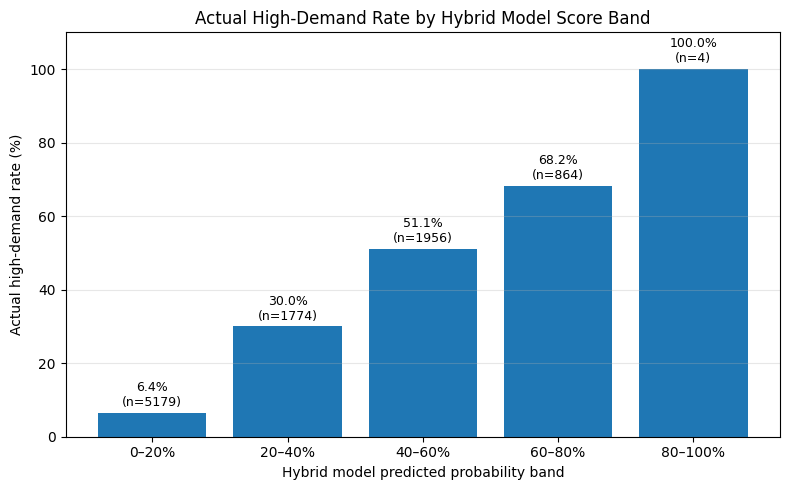

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Option A: use this if you are running directly after the notebook's prediction cell
df_scores = test_predictions.copy()

# Option B: use this instead if loading the saved output later
# df_scores = pd.read_csv("hybrid_airbnb_test_predictions.csv")

# Create probability score bands
df_scores["score_band"] = pd.cut(
    df_scores["hybrid_high_demand_prob"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=["0–20%", "20–40%", "40–60%", "60–80%", "80–100%"],
    include_lowest=True
)

# Calculate actual high-demand rate and sample size per band
band_summary = (
    df_scores
    .groupby("score_band", observed=False)
    .agg(
        actual_high_demand_rate=("high_demand", "mean"),
        listings=("high_demand", "count")
    )
    .reset_index()
)

band_summary["actual_high_demand_rate_pct"] = (
    band_summary["actual_high_demand_rate"] * 100
)

display(band_summary)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    band_summary["score_band"].astype(str),
    band_summary["actual_high_demand_rate_pct"]
)

ax.set_title("Actual High-Demand Rate by Hybrid Model Score Band")
ax.set_xlabel("Hybrid model predicted probability band")
ax.set_ylabel("Actual high-demand rate (%)")
ax.set_ylim(0, max(100, band_summary["actual_high_demand_rate_pct"].max() + 10))
ax.grid(axis="y", alpha=0.3)

# Add labels above bars
for bar, rate, n in zip(
    bars,
    band_summary["actual_high_demand_rate_pct"],
    band_summary["listings"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{rate:.1f}%\n(n={n})",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("actual_high_demand_rate_by_hybrid_score_band.png", dpi=300, bbox_inches="tight")
plt.show()